# Imports

In [1]:
import sys
print(sys.executable)

/home/sarah/Desktop/University/ComputerVision/SensiFake/.venv/bin/python


In [2]:
from pathlib import Path
from tqdm.auto import tqdm
import os
import random
import hashlib
import json
from uuid import uuid4
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import torch
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from huggingface_hub import hf_hub_download
import zipfile
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms


/home/sarah/Desktop/University/ComputerVision/SensiFake/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Globals

In [3]:
#=======================
# Data Configuration
#=======================
CSV_PATH = None # used for testing purposes, now the data is loaded from the kaggle dataset.
IMAGE_ROOT = None # used for testing purposes, now the data is loaded from the kaggle dataset.
OUTPUT_DIR = Path("SensiFakeProject-output-v2")  # Includes v2 checkpoints and results.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


#=======================
# Model Configuration
#=======================
MODEL_NAME = "resnet50"
USE_PRETRAINED = True
IMAGE_SIZE = 224
RANDOM_SEED = 35
BATCH_SIZE = 64
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # DO NOT CHANGE THE WORKERS VALUE. It is set to 0 to avoid issues with Windows and Jupyter notebooks.
FREEZE_BACKBONE_EPOCHS = 1  # 0 disables initial freezing.
EARLY_STOPPING_PATIENCE = 2
TRAINING_SIZE = 0.7
VALIDATION_FRACTION = 0.1
TEST_FRACTION = 0.2
TRAINING_RUN_ID = uuid4().hex  # Reject checkpoints from previous notebook runs.

DETERMINISTIC = False  # Enable strict deterministic kernels when needed.
SENSITIVITY_NAMES = {}  # Optional, e.g. {0: "Low", 1: "High"}.


#=======================
# Device Configuration
#=======================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = not DETERMINISTIC

# optimization settigs if the system detect a GPU
PIN_MEMORY = DEVICE.type == "cuda" 
USE_AMP = DEVICE.type == "cuda"
# Controlled v2 training settings
ADN_DROPOUT = 0.3
ADN_LABEL_SMOOTHING = 0.05
CSN_HUMAN_WEIGHT = 1.5
CSN_AUTO_WEIGHT = 1.0
CSN_CLASS_WEIGHTS = {"low": 1.0, "medium": 1.0, "high": 2.0}
TRAIN_AUGMENTATION = {
    "horizontal_flip_probability": 0.5,
    "color_jitter": {"brightness": 0.1, "contrast": 0.1, "saturation": 0.0, "hue": 0.0},
}

# ADN progressive fine-tuning
ADN_HEAD_ONLY_EPOCHS = 2
ADN_HEAD_LR = LEARNING_RATE
ADN_LAYER4_LR = ADN_HEAD_LR / 10
ADN_CROP_SCALE = (0.90, 1.0)
ADN_CROP_RATIO = (0.95, 1.05)



Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# Utils

In [4]:
# Output saving: all v2 results and checkpoints share the isolated directory.
RESULTS_DIR = OUTPUT_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed=RANDOM_SEED, deterministic=DETERMINISTIC):
    """Set the random seed for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "cuda":
        torch.cuda.manual_seed_all(seed)
        if deterministic:
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

            
def calculate_metrics(y_true, y_pred, average="weighted"):
    """Return the common classification metrics with safe zero division."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }


# Result files and related plotting helpers.
def _save_figure(fig, filename):
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def _save_training_history(history, task):
    # CSV column names explicitly identify validation metrics.
    frame = pd.DataFrame({key: values for key, values in history.items()
                          if key != "confusion_matrix"}).rename(columns={
        "val_loss": "validation_loss", "val_accuracy": "validation_accuracy",
        "val_macro_f1": "validation_macro_f1",
        "val_high_recall": "validation_high_recall", "val_high_f1": "validation_high_f1",
    })
    frame.insert(0, "epoch", np.arange(1, len(frame) + 1))
    filename = f"{task.lower()}_training_history.csv"
    frame.to_csv(RESULTS_DIR / filename, index=False)



def _save_metrics(metrics, filename):
    # Preserve metric values; undefined metrics become standard JSON null.
    def json_values(values):
        return {
            key.lower().replace(" ", "_").replace("-", "_"):
                json_values(value) if isinstance(value, dict)
                else float(value) if pd.notna(value) else None
            for key, value in values.items()
        }
    (RESULTS_DIR / filename).write_text(
        json.dumps(json_values(metrics), indent=2, allow_nan=False) + "\n", encoding="utf-8"
    )


def plot_training_history(history, title):
    """Exactly three panels: loss, accuracy and validation Macro F1."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set(title=f"{title} loss", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[1].plot(epochs, history["train_accuracy"], label="Train")
    axes[1].plot(epochs, history["val_accuracy"], label="Validation")
    axes[1].set(title=f"{title} accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend()
    axes[2].plot(epochs, history["val_macro_f1"], label="Validation")
    axes[2].set(title=f"{title} validation Macro F1", xlabel="Epoch", ylabel="Macro F1")
    axes[2].legend()
    _save_figure(fig, f"{title.lower()}_training.jpg")



def plot_training_confusion(history, title, class_names):
    best_epoch = int(np.argmax(history["val_macro_f1"]))
    matrix = history["confusion_matrix"][best_epoch]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set(title=f"{title} Best Validation Confusion Matrix (Epoch {best_epoch + 1})",
           xlabel="Predicted", ylabel="True")
    _save_figure(fig, f"{title.lower()}_training_confusion_matrix.jpg")


def save_checkpoint(path, model, task, class_names, epoch, best_metric, class_to_index):
    path = Path(path)
    assert path.parent == OUTPUT_DIR
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "task": task,
        "model_name": MODEL_NAME,
        "num_classes": len(class_names),
        "class_names": list(class_names),
        "class_to_index": {str(value): int(index) for value, index in class_to_index.items()},
        "split_fingerprint": split_fingerprint,
        "training_run_id": TRAINING_RUN_ID,
        "epoch": int(epoch),
        "best_val_f1": float(best_metric),  # Retained metadata key; v3 explicitly uses Macro F1.
        "best_val_macro_f1": float(best_metric),
        "selection_metric": "validation_macro_f1",
        "model_state_dict": model.state_dict(),
    }, path)



def load_checkpoint(path, model, map_location=DEVICE):
    """Load weights while supporting PyTorch versions with/without weights_only."""
    try:
        checkpoint = torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        checkpoint = torch.load(path, map_location=map_location)
    if (checkpoint.get("split_fingerprint") != split_fingerprint
            or checkpoint.get("training_run_id") != TRAINING_RUN_ID):
        raise ValueError("Checkpoint not produced by training on the current global split/run. "
                         "Run the ADN and CSN training cells before evaluation.")
    assert checkpoint.get("selection_metric") == "validation_macro_f1"
    state = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state)
    return checkpoint


def cleanup_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _plot_validation_confusion(y_true, y_pred, names, task, normalize=None):
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(names))), normalize=normalize)
    fig, ax = plt.subplots(figsize=(6, 5))
    options = {"vmin": 0, "vmax": 1, "cbar_kws": {"label": "Fraction of true class"}} if normalize else {}
    sns.heatmap(matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", ax=ax,
                xticklabels=names, yticklabels=names, **options)
    ax.set(title=f"{task} — Best-checkpoint Validation", xlabel="Predicted", ylabel="True")
    suffix = "_normalized" if normalize else ""
    _save_figure(fig, f"{task.lower()}_validation_confusion_matrix{suffix}.jpg")



# Data

### The following code is the download and extraction from huggingface dataset.


In [5]:
zip_path = hf_hub_download(
    repo_id="K4ru4k4i/SensiFake",
    filename="final_dataset.zip",
    repo_type="dataset"
)

extract_dir = "./sensifake"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Dataset pronto in:", extract_dir)

path = Path(extract_dir)/"final_dataset"

Dataset pronto in: ./sensifake


### Global split 70/10/20
Un solo split condiviso da ADN e CSN. La stratificazione congiunta viene tentata su entrambe le divisioni; se non è fattibile si usa real/fake, poi uno split casuale con lo stesso seed. Il test resta escluso da training e selezione dei checkpoint.

In [6]:
metadata_files = list(path.rglob("sensifake_all.csv"))


if not metadata_files:
    raise FileNotFoundError(f"No metadata found in {path}")

metadata_path = metadata_files[0]
df = pd.read_csv(metadata_path)

Dataset_root = metadata_path.parent.parent
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Metadata: {metadata_path}")
print(f"Dataset shape: {df.shape}")
print("Columns:", list(df.columns))

# Detect label columns
label_candidates = ["label","real_fake_label"]
sensitivity_candidates = ["sensitivity","final_sensitivity_score"]

label_col = next((col for col in label_candidates if col in df.columns), None)
sensitivity_col = next((col for col in sensitivity_candidates if col in df.columns), None)

if label_col is None:
    raise ValueError(
        f"Could not identify the real/fake label column. Available columns: {list(df.columns)}"
    )

if sensitivity_col is None:
    raise ValueError("Could not identify the sensitivity label column.")
if df[[label_col, sensitivity_col]].isna().any().any():
    raise ValueError("Missing target labels: fix the metadata before splitting.")

# Preserve the original path handling before creating the shared subsets.
image_candidates = ["image", "image_path", "filepath", "file_path", "filename", "file"]
image_col = next((col for col in image_candidates if col in df.columns), None)
if image_col is None:
    raise ValueError("Could not identify the image path column.")
df["image_path"] = df[image_col].apply(lambda path: str(path))
if df["image_path"].duplicated().any():
    raise ValueError("Repeated image paths would allow image leakage between subsets.")

# Global split helpers: two divisions define a single shared 70/10/20 partition.
def _global_split(frame):
    assert np.isclose(TRAINING_SIZE + VALIDATION_FRACTION + TEST_FRACTION, 1.0)
    joint = frame[[label_col, sensitivity_col]].astype(str).agg("_".join, axis=1)
    candidates = [("real/fake + sensitivity", joint),
                  ("real/fake", frame[label_col].astype(str)), ("random", None)]
    failures = []
    for strategy, stratify_values in candidates:
        try:
            train_val, test_part = train_test_split(
                frame, test_size=TEST_FRACTION, random_state=RANDOM_SEED,
                shuffle=True, stratify=stratify_values,
            )
            remaining_strata = (None if stratify_values is None
                                else stratify_values.loc[train_val.index])
            train_part, val_part = train_test_split(
                train_val, test_size=VALIDATION_FRACTION / (1.0 - TEST_FRACTION),
                random_state=RANDOM_SEED, shuffle=True, stratify=remaining_strata,
            )
        except ValueError as exc:
            failures.append(f"{strategy}: {exc}")
            continue
        print(f"Split stratification: {strategy}")
        if failures:
            print("Fallback:", " | ".join(failures))
        return train_part, val_part, test_part
    raise ValueError("Cannot create the global split: " + " | ".join(failures))

train_df, val_df, test_df = _global_split(df)
split_indices = [set(frame.index) for frame in (train_df, val_df, test_df)]
assert not (split_indices[0] & split_indices[1] or split_indices[0] & split_indices[2]
            or split_indices[1] & split_indices[2])
assert set.union(*split_indices) == set(df.index)

# Checkpoint provenance hashes train/validation membership only; the split itself is unchanged.
split_hasher = hashlib.sha256()
split_hasher.update(str((RANDOM_SEED, TRAINING_SIZE, VALIDATION_FRACTION, TEST_FRACTION)).encode())
for name, frame in (("train", train_df), ("validation", val_df)):
    split_hasher.update(name.encode())
    split_hasher.update(pd.util.hash_pandas_object(
        frame[["image_path", label_col, sensitivity_col]], index=True
    ).values.tobytes())
split_fingerprint = split_hasher.hexdigest()
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Total images: {len(df)}")
split_summary = pd.DataFrame([
    {"split": name, "size": len(frame), "fraction": len(frame) / len(df),
     "real/fake": frame[label_col].value_counts().sort_index().to_dict(),
     "sensitivity": frame[sensitivity_col].value_counts().sort_index().to_dict()}
    for name, frame in (("train", train_df), ("validation", val_df))
]).set_index("split")
print(split_summary.to_string())

# Class mappings keep the original sorted-label encoding.
adn_class_values = sorted(train_df[label_col].unique())
csn_class_values = sorted(train_df[sensitivity_col].unique())
if (set(adn_class_values) != set(df[label_col].unique())
        or set(csn_class_values) != set(df[sensitivity_col].unique())):
    raise ValueError("A class is absent from training. Cannot keep the original class-weight strategy.")
adn_class_to_index = {value: index for index, value in enumerate(adn_class_values)}
csn_class_to_index = {value: index for index, value in enumerate(csn_class_values)}
adn_class_names = [str(value) for value in adn_class_values]
csn_class_names = [SENSITIVITY_NAMES.get(value, str(value)) for value in csn_class_values]

# Release schema: authenticity 0=Real, 1=Fake; sensitivity 0=Low, 1=Medium, 2=High.
# Named labels are supported without changing their original index order.
def _semantic_indices(class_to_index, numeric_names, name_col=None):
    indices = {}
    value_names = {}
    for value, index in class_to_index.items():
        text = str(value).strip().lower()
        if text in numeric_names.values():
            name = text
        elif value in numeric_names:
            name = numeric_names[value]
        elif text in {str(key): name for key, name in numeric_names.items()}:
            name = {str(key): name for key, name in numeric_names.items()}[text]
        else:
            raise ValueError(f"Unknown label meaning: {value!r}; check the dataset schema.")
        if name in indices:
            raise ValueError(f"Multiple label values represent {name}.")
        indices[name] = index
        value_names[value] = name
    assert set(indices) == set(numeric_names.values()), "Missing or unexpected classes."
    if name_col is not None and name_col in df.columns:
        target_col = label_col if name_col == "real_fake_label_name" else sensitivity_col
        expected = df[target_col].map(value_names)
        assert expected.equals(df[name_col].astype(str).str.strip().str.lower()), (
            f"Numeric labels disagree with {name_col}; do not reinterpret their meaning."
        )
    return indices

adn_indices = _semantic_indices(adn_class_to_index, {0: "real", 1: "fake"}, "real_fake_label_name")
csn_indices = _semantic_indices(csn_class_to_index, {0: "low", 1: "medium", 2: "high"}, "final_sensitivity_label")
adn_display_names = [next(name.title() for name, index in adn_indices.items() if index == i)
                     for i in range(len(adn_class_to_index))]
csn_display_names = [next(name.title() for name, index in csn_indices.items() if index == i)
                     for i in range(len(csn_class_to_index))]
print("ADN class_to_index:", adn_class_to_index, "semantic indices:", adn_indices)
print("CSN class_to_index:", csn_class_to_index, "semantic indices:", csn_indices)
# CSN sample weights: identify annotation provenance through release-relative folders.
def _annotation_masks(frame):
    paths = frame["image_path"].astype(str).str.replace("\\", "/", regex=False)
    human = paths.str.fullmatch(r"human_annotated/images/[^/]+")
    automatic = paths.str.fullmatch(r"autoannotated/images/[^/]+")
    if not (human | automatic).all():
        examples = paths.loc[~(human | automatic)].head(3).tolist()
        raise ValueError(f"Unrecognized annotation folders: {examples}. "
                         "Cannot assign CSN weights safely; inspect the dataset organization.")
    if "annotation_type" in frame.columns:
        expected = pd.Series(np.where(human, "human", "automatic"), index=frame.index)
        if not expected.equals(frame["annotation_type"].astype(str).str.strip().str.lower()):
            raise ValueError("Annotation metadata disagrees with the image folders; CSN weights halted.")
    assert not (human & automatic).any()
    assert int(human.sum()) + int(automatic.sum()) == len(frame)
    return human, automatic

full_human_mask, full_auto_mask = _annotation_masks(df)
full_human_count = int(full_human_mask.sum())
human_source_counts = {}
if "human_annotation_source" in df.columns:
    human_source_counts = df.loc[full_human_mask, "human_annotation_source"].value_counts().to_dict()
if full_human_count != 701:
    print(f"Human annotation count differs from the expected 701: detected {full_human_count}.")
    print("Existing human annotation sources:", human_source_counts)
    # This local release documents 701 original annotations plus 400 reviewed additions.
    stats_path = metadata_path.parent / "dataset_statistics.json"
    stats = json.loads(stats_path.read_text(encoding="utf-8")) if stats_path.is_file() else {}
    sources = stats.get("canonical_human_source_counts", {})
    documented_extension = (
        full_human_count == 1101
        and human_source_counts == {"human_master_final": 701, "consolidated_human_review": 400}
        and stats.get("human_annotated_images") == full_human_count
        and sources == {"original_final_master": 701, "consolidated_final_review": 400, "overlap": 0}
    )
    if not documented_extension:
        raise ValueError("Unexplained human annotation count discrepancy. "
                         "Training halted rather than guessing a subset or its weights.")
    print("Confirmed by release statistics: 701 original + 400 reviewed additions. "
          "All 1,101 human-folder samples receive the human factor; labels and split are unchanged.")

train_human_mask, train_auto_mask = _annotation_masks(train_df)
train_human_count = int(train_human_mask.sum())
train_auto_count = int(train_auto_mask.sum())
assert train_human_count + train_auto_count == len(train_df)

# Reproducibility record: configuration is frozen from v3 training/validation; test performance never informs these choices.
training_config = {
    "random_seed": RANDOM_SEED,
    "epochs": NUM_EPOCHS,
    "adn_trainable_layers": {"initial": ["backbone.fc"],
                             "after_head_only_epochs": ["backbone.layer4", "backbone.fc"]},
    "adn_head_only_epochs": ADN_HEAD_ONLY_EPOCHS,
    "adn_head_lr": ADN_HEAD_LR,
    "adn_layer4_lr": ADN_LAYER4_LR,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "adn_dropout": ADN_DROPOUT,
    "adn_label_smoothing": ADN_LABEL_SMOOTHING,
    "csn_human_weight": CSN_HUMAN_WEIGHT,
    "csn_auto_weight": CSN_AUTO_WEIGHT,
    **{f"csn_{name}_weight": weight for name, weight in CSN_CLASS_WEIGHTS.items()},
    "augmentation": {"train": TRAIN_AUGMENTATION,
                     "adn_training_crop": {"scale": ADN_CROP_SCALE, "ratio": ADN_CROP_RATIO},
                     "validation_test_demo": "unchanged deterministic resize/tensor/normalize"},
    "human_path_pattern": "human_annotated/images/",
    "auto_path_pattern": "autoannotated/images/",
    "expected_original_human_count": 701,
    "full_dataset_human_count": full_human_count,
    "full_dataset_human_annotation_sources": human_source_counts,
    "train_human_count": train_human_count,
    "train_auto_count": train_auto_count,
    "train_sensitivity_counts": {
        name: int((train_df[sensitivity_col].map(csn_class_to_index) == csn_indices[name]).sum())
        for name in ("low", "medium", "high")
    },
    "split_fractions": {"train": TRAINING_SIZE, "validation": VALIDATION_FRACTION, "test": TEST_FRACTION},
    "split_fingerprint": split_fingerprint,
    "csn_freeze_backbone_epochs": FREEZE_BACKBONE_EPOCHS,
    "checkpoint_selection": "validation_macro_f1",
    "early_stopping_metric": "validation_macro_f1",
    "configuration_source": "SensiFakeProject-v3-validation.ipynb (training/validation only)",
}
(RESULTS_DIR / "training_config.json").write_text(
    json.dumps(training_config, indent=2, allow_nan=False) + "\n", encoding="utf-8"
)


Metadata: sensifake/final_dataset/metadata/sensifake_all.csv
Dataset shape: (4499, 29)
Columns: ['image_id', 'image_path', 'source_dataset', 'source_original_path', 'source_original_paths_json', 'sha256', 'source_dataset_url', 'source_dataset_license', 'source_original_id', 'source_requested_revision', 'source_resolved_revision', 'real_fake_label', 'real_fake_label_name', 'real_fake_label_provenance', 'annotation_type', 'sensitivity_label_quality', 'human_annotation_available', 'human_annotation_source', 'human_sensitivity_score', 'human_sensitivity_label', 'predicted_sensitivity_score', 'predicted_sensitivity_label', 'p_ge_1', 'p_ge_2', 'final_sensitivity_score', 'final_sensitivity_label', 'model_version', 'checkpoint_sha256', 'v3_supervision_split']
Split stratification: real/fake + sensitivity
Total images: 4499
            size  fraction           real/fake                sensitivity
split                                                                    
train       3149  0.69993

1844

# Network

### The following code define the model architecture and the training loop. It also includes functions for evaluating the model on the validation set and saving the best model based on validation performance.

In [7]:
def create_base_model(num_classes, pretrained=USE_PRETRAINED):
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    try:
        network = models.resnet50(weights=weights)
    except Exception as exc:
        if pretrained:
            raise RuntimeError(
                "Failed to load pretrained weights. Set USE_PRETRAINED=False to initialize randomly."
            ) from exc
        raise
    network.fc = nn.Linear(network.fc.in_features, num_classes)
    return network


class ADN(nn.Module):
    """Independent image-only real/fake classifier with two output logits."""
    def __init__(self, pretrained=USE_PRETRAINED):
        super().__init__()
        self.backbone = create_base_model(num_classes=2, pretrained=pretrained)
        # ADN regularization: one dropout immediately before the existing classifier.
        classifier = self.backbone.fc
        self.backbone.fc = nn.Sequential(nn.Dropout(p=ADN_DROPOUT), classifier)
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for component in (self.backbone.fc,):
            for parameter in component.parameters():
                parameter.requires_grad = True

    def train(self, mode=True):
        super().train(mode)
        # Frozen early BatchNorm statistics must also remain fixed during training.
        if mode:
            for name, component in self.backbone.named_children():
                if name != "fc" and not any(parameter.requires_grad for parameter in component.parameters()):
                    component.eval()
        return self

    def forward(self, image):
        return self.backbone(image)

class CSN(nn.Module):
    """Independent image-only sensitivity classifier."""
    def __init__(self, num_sensitivity_classes, pretrained=USE_PRETRAINED):
        super().__init__()
        if num_sensitivity_classes < 2:
            raise ValueError("At least two sensitivity classes are required for classification.")
        self.backbone = create_base_model(num_classes=num_sensitivity_classes, pretrained=pretrained)

    def forward(self, image):
        return self.backbone(image)

    

# Train

#### Training function and class definition

In [8]:
class ImageClassificationDataset(Dataset):
    def __init__(self, frame, target_col, class_to_index, transform=None, sample_weights=None):
        self.frame = frame.reset_index(drop=True)
        self.target_col = target_col
        self.class_to_index = class_to_index
        self.transform = transform
        self.sample_weights = (None if sample_weights is None
                               else np.asarray(sample_weights, dtype=np.float32))
        if self.sample_weights is not None:
            assert len(self.sample_weights) == len(self.frame)
            assert np.isfinite(self.sample_weights).all() and (self.sample_weights > 0).all()

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_path = Dataset_root / str(row["image_path"])

        try:
            image = Image.open(image_path).convert("RGB")
        except (FileNotFoundError, UnidentifiedImageError) as exc:
            raise RuntimeError(f"Could not load image: {image_path}") from exc

        if self.transform:
            image = self.transform(image)

        label = self.class_to_index[row[self.target_col]]
        label = torch.tensor(label, dtype=torch.long)
        if self.sample_weights is not None:
            return image, label, torch.tensor(self.sample_weights[index], dtype=torch.float32)
        return image, label


def _make_transforms(task=None):
    weights = models.ResNet50_Weights.DEFAULT
    preprocess = weights.transforms()

    normalize = transforms.Normalize(
        mean=preprocess.mean,
        std=preprocess.std,
    )

    # ADN alone receives a conservative crop after the existing resize.
    spatial_transforms = [transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))]
    if task == "ADN":
        spatial_transforms.append(transforms.RandomResizedCrop(
            IMAGE_SIZE, scale=ADN_CROP_SCALE, ratio=ADN_CROP_RATIO
        ))
    train_transform = transforms.Compose([
        *spatial_transforms,
        # Training augmentation: retain the current resize and horizontal flip.
        transforms.RandomHorizontalFlip(p=TRAIN_AUGMENTATION["horizontal_flip_probability"]),
        transforms.ColorJitter(**TRAIN_AUGMENTATION["color_jitter"]),
        transforms.ToTensor(),
        normalize,
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        normalize,
    ])

    return train_transform, eval_transform


# DataLoader helpers: receive the global subsets without splitting again.
def _build_loaders(train_part, val_part, target_col, class_to_index, train_sample_weights=None, task=None):
    assert train_part.equals(train_df) and val_part.equals(val_df), "Loaders must use the shared train/validation split."
    train_transform, eval_transform = _make_transforms(task=task)
    train_dataset = ImageClassificationDataset(
        train_part, target_col, class_to_index, train_transform, sample_weights=train_sample_weights
    )
    val_dataset = ImageClassificationDataset(
        val_part, target_col, class_to_index, eval_transform
    )
    train_loader = DataLoader(
        train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader


def _build_test_loader(frame, target_col, class_to_index):
    _, eval_transform = _make_transforms()
    dataset = ImageClassificationDataset(frame, target_col, class_to_index, eval_transform)
    return DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )



def _set_backbone_trainable(model, trainable):
    for parameter in model.backbone.parameters():
        parameter.requires_grad = trainable

    for parameter in model.backbone.fc.parameters():
        parameter.requires_grad = True


def _evaluate(model, loader, criterion):
    assert loader.dataset.sample_weights is None
    model.eval()
    total_loss = 0.0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())

    metrics = calculate_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / len(loader.dataset)
    labels = list(range(len(loader.dataset.class_to_index)))
    metrics["macro_f1"] = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    metrics["y_true"] = np.asarray(y_true)
    metrics["y_pred"] = np.asarray(y_pred)
    if loader.dataset.target_col == sensitivity_col:
        metrics["class_report"] = classification_report(
            y_true, y_pred, labels=labels, target_names=csn_display_names,
            output_dict=True, zero_division=0,
        )
        metrics["high_recall"] = metrics["class_report"]["High"]["recall"]
        metrics["high_f1"] = metrics["class_report"]["High"]["f1-score"]
    return metrics


# ADN progressive fine-tuning
def _set_adn_stage(model, train_layer4):
    _set_backbone_trainable(model, False)
    for parameter in model.backbone.layer4.parameters():
        parameter.requires_grad = train_layer4
    assert all(parameter.requires_grad for parameter in model.backbone.fc.parameters())
    assert all(parameter.requires_grad == train_layer4 for parameter in model.backbone.layer4.parameters())
    assert all(not parameter.requires_grad for name, parameter in model.backbone.named_parameters()
               if not name.startswith(("layer4.", "fc.")))


def _assert_optimizer_trainable(model, optimizer):
    optimized = [parameter for group in optimizer.param_groups for parameter in group["params"]]
    assert all(parameter.requires_grad for parameter in optimized)
    assert len(optimized) == len({id(parameter) for parameter in optimized})
    assert {id(parameter) for parameter in optimized} == {
        id(parameter) for parameter in model.parameters() if parameter.requires_grad
    }


def _train_classifier(model, train_loader, val_loader, criterion, task, class_names, class_to_index,
                      validation_criterion=None):
    model = model.to(DEVICE)
    if task == "ADN":
        _set_adn_stage(model, train_layer4=False)
        optimizer = torch.optim.AdamW(
            [{"params": list(model.backbone.fc.parameters()), "lr": ADN_HEAD_LR}],
            lr=ADN_HEAD_LR, weight_decay=WEIGHT_DECAY,
        )
    else:
        optimizer = torch.optim.AdamW(
            filter(lambda parameter: parameter.requires_grad, model.parameters()),
            lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
        )
    _assert_optimizer_trainable(model, optimizer)
    scaler = GradScaler(enabled=USE_AMP)
    history = {"train_loss": [], "val_loss": [], "train_accuracy": [],
               "val_accuracy": [], "val_macro_f1": [], "confusion_matrix": []}
    if task == "CSN":
        history.update({"val_high_recall": [], "val_high_f1": []})

    best_f1 = -np.inf
    best_epoch = 0
    patience_counter = 0
    checkpoint_path = Path(OUTPUT_DIR) / f"{task.lower()}_best.pt"
    checkpoint_saved = False
    for epoch in range(NUM_EPOCHS):
        if task == "ADN" and epoch == ADN_HEAD_ONLY_EPOCHS:
            _set_adn_stage(model, train_layer4=True)
            # Keep the head's AdamW state when adding the lower-LR layer4 group.
            optimizer.add_param_group({
                "params": list(model.backbone.layer4.parameters()), "lr": ADN_LAYER4_LR,
            })
        elif task == "CSN" and epoch == FREEZE_BACKBONE_EPOCHS:
            # Preserve CSN's v2 freeze/unfreeze schedule and optimizer family.
            _set_backbone_trainable(model, True)
            optimizer = torch.optim.AdamW(
                filter(lambda parameter: parameter.requires_grad, model.parameters()),
                lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
            )
        _assert_optimizer_trainable(model, optimizer)
        if task == "ADN":
            assert optimizer.param_groups[0]["lr"] == ADN_HEAD_LR
            if epoch >= ADN_HEAD_ONLY_EPOCHS:
                assert optimizer.param_groups[1]["lr"] == ADN_LAYER4_LR

        model.train()
        running_loss = 0.0
        y_true, y_pred = [], []
        progress = tqdm(train_loader, desc=f"{task} epoch {epoch + 1}/{NUM_EPOCHS}")
        for batch in progress:
            images, labels = batch[:2]
            sample_weights = batch[2].to(DEVICE, non_blocking=True) if len(batch) == 3 else None
            assert (sample_weights is not None) == (task == "CSN")
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, labels)
                if sample_weights is not None:
                    # CSN weighted loss: unchanged v2 annotation/class factors.
                    assert loss.shape == sample_weights.shape == labels.shape
                    loss = (loss * sample_weights).mean()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * labels.size(0)
            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy())

        train_metrics = calculate_metrics(y_true, y_pred)
        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = _evaluate(
            model, val_loader, criterion if validation_criterion is None else validation_criterion
        )
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["confusion_matrix"].append(val_metrics["confusion_matrix"])
        message = (
            f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {val_metrics['loss']:.4f} | "
            f"Train Accuracy: {train_metrics['accuracy']:.4f} | "
            f"Validation Accuracy: {val_metrics['accuracy']:.4f} | "
            f"Validation Macro F1: {val_metrics['macro_f1']:.4f}"
        )
        if task == "CSN":
            history["val_high_recall"].append(val_metrics["high_recall"])
            history["val_high_f1"].append(val_metrics["high_f1"])
            message += (f" | Validation High Recall: {val_metrics['high_recall']:.4f}"
                        f" | Validation High F1: {val_metrics['high_f1']:.4f}")
        print(message)

        # Selection and early stopping both use validation Macro F1 only.
        if val_metrics["macro_f1"] > best_f1:
            best_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            patience_counter = 0
            save_checkpoint(checkpoint_path, model, task, class_names, best_epoch,
                            best_f1, class_to_index)
            checkpoint_saved = True
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("Early stopping.")
                break
    if not checkpoint_saved:
        raise RuntimeError(f"{task}: no valid best checkpoint was saved in this training run.")
    load_checkpoint(checkpoint_path, model)
    return model, history, checkpoint_path


def train_adn():
    class_to_index = adn_class_to_index
    class_names = adn_class_names
    train_loader, val_loader = _build_loaders(
        train_df, val_df, label_col, class_to_index, task="ADN"
    )

    model = ADN(pretrained=USE_PRETRAINED)
    _set_adn_stage(model, train_layer4=False)
    criterion = nn.CrossEntropyLoss(label_smoothing=ADN_LABEL_SMOOTHING)

    return _train_classifier(
        model, train_loader, val_loader, criterion, "ADN", class_names, class_to_index
    )


def train_csn():
    class_values = csn_class_values
    class_to_index = csn_class_to_index
    class_names = csn_class_names
    # CSN sample weights: use training paths and unchanged training labels only.
    human, automatic = _annotation_masks(train_df)
    human_count, auto_count = int(human.sum()), int(automatic.sum())
    assert human_count + auto_count == len(train_df)
    annotation_weights = np.where(human, CSN_HUMAN_WEIGHT, CSN_AUTO_WEIGHT)
    encoded_labels = train_df[sensitivity_col].map(class_to_index).to_numpy()
    class_weights = np.ones(len(class_to_index), dtype=np.float32)
    for name, factor in CSN_CLASS_WEIGHTS.items():
        class_weights[csn_indices[name]] = factor
    sample_weights = (annotation_weights * class_weights[encoded_labels]).astype(np.float32)
    assert np.isin(sample_weights, [1.0, 1.5, 2.0, 3.0]).all()
    print("CSN weighting diagnostic:", {
        "total_training_samples": len(train_df), "human": human_count, "auto": auto_count,
        "sensitivity_counts": {name.title(): int((encoded_labels == csn_indices[name]).sum())
                               for name in ("low", "medium", "high")},
        "min_sample_weight": float(sample_weights.min()), "max_sample_weight": float(sample_weights.max()),
        "weight_counts": {str(weight): int((sample_weights == weight).sum())
                          for weight in (1.0, 1.5, 2.0, 3.0)},
    })
    print("Human path examples:", train_df.loc[human, "image_path"].head(3).tolist())
    print("Auto path examples:", train_df.loc[automatic, "image_path"].head(3).tolist())
    train_loader, val_loader = _build_loaders(
        train_df, val_df, sensitivity_col, class_to_index, train_sample_weights=sample_weights, task="CSN"
    )

    model = CSN(
        num_sensitivity_classes=len(class_values),
        pretrained=USE_PRETRAINED,
    )
    _set_backbone_trainable(model, FREEZE_BACKBONE_EPOCHS == 0)

    criterion = nn.CrossEntropyLoss(reduction="none")
    # Validation is unweighted; sample/class factors belong to the training loss only.
    validation_criterion = nn.CrossEntropyLoss()

    return _train_classifier(
        model, train_loader, val_loader, criterion, "CSN", class_names, class_to_index,
        validation_criterion=validation_criterion
    )


# Evaluation

In [9]:
# Train both classifiers; selection and early stopping use validation Macro F1 only.
set_seed()

adn_model, adn_history, adn_checkpoint = train_adn()

cleanup_gpu_memory()

csn_model, csn_history, csn_checkpoint = train_csn()


print(f"ADN checkpoint: {adn_checkpoint}")
print(f"CSN checkpoint: {csn_checkpoint}")

/tmp/ipykernel_577732/3901612136.py:177: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)
ADN epoch 1/8:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_577732/3901612136.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 1/8: 100%|██████████| 50/50 [01:30<00:00,  1.81s/it]
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1 | Train Loss: 0.6776 | Validation Loss: 0.6620 | Train Accuracy: 0.5722 | Validation Accuracy: 0.6222 | Validation Macro F1: 0.6216


ADN epoch 2/8:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_577732/3901612136.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 2/8: 100%|██████████| 50/50 [01:12<00:00,  1.46s/it]
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 2 | Train Loss: 0.6463 | Validation Loss: 0.6362 | Train Accuracy: 0.6396 | Validation Accuracy: 0.6956 | Validation Macro F1: 0.6956


ADN epoch 3/8:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_577732/3901612136.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
ADN epoch 3/8: 100%|██████████| 50/50 [01:16<00:00,  1.53s/it]
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


...

Epoch 3 | Train Loss: 0.3995 | Validation Loss: 0.4312 | Train Accuracy: 0.8943 | Validation Accuracy: 0.8511 | Validation Macro F1: 0.7385 | Validation High Recall: 0.4091 | Validation High F1: 0.5294


CSN epoch 4/8:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_577732/3901612136.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
CSN epoch 4/8: 100%|██████████| 50/50 [01:17<00:00,  1.55s/it]
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 4 | Train Loss: 0.2011 | Validation Loss: 0.4582 | Train Accuracy: 0.9549 | Validation Accuracy: 0.8422 | Validation Macro F1: 0.7333 | Validation High Recall: 0.4545 | Validation High F1: 0.5405


CSN epoch 5/8:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_577732/3901612136.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
CSN epoch 5/8: 100%|██████████| 50/50 [01:19<00:00,  1.60s/it]
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 5 | Train Loss: 0.1018 | Validation Loss: 0.4938 | Train Accuracy: 0.9813 | Validation Accuracy: 0.8289 | Validation Macro F1: 0.7217 | Validation High Recall: 0.4545 | Validation High F1: 0.5263
Early stopping.
ADN checkpoint: SensiFakeProject-output-v2/adn_best.pt
CSN checkpoint: SensiFakeProject-output-v2/csn_best.pt


#### Little script to see witch parameters are saved in the training loop

In [10]:
for name, history in [("ADN", adn_history), ("CSN", csn_history)]:
    print(f"\n{name}")
    _save_training_history(history, name)
    for key, values in history.items():
        print(f"  {key}: {len(values)} values")



ADN
  train_loss: 8 values
  val_loss: 8 values
  train_accuracy: 8 values
  val_accuracy: 8 values
  val_macro_f1: 8 values
  confusion_matrix: 8 values

CSN
  train_loss: 5 values
  val_loss: 5 values
  train_accuracy: 5 values
  val_accuracy: 5 values
  val_macro_f1: 5 values
  confusion_matrix: 5 values
  val_high_recall: 5 values
  val_high_f1: 5 values


### Code for plotting the models metrics

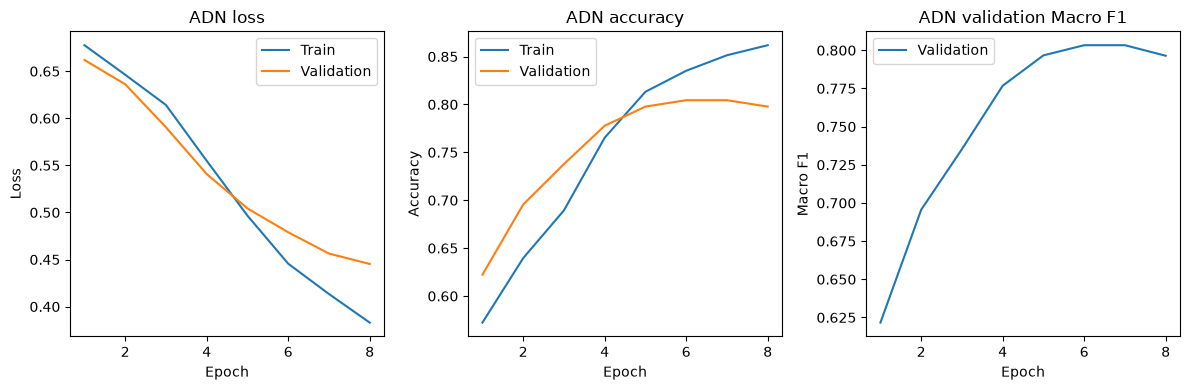

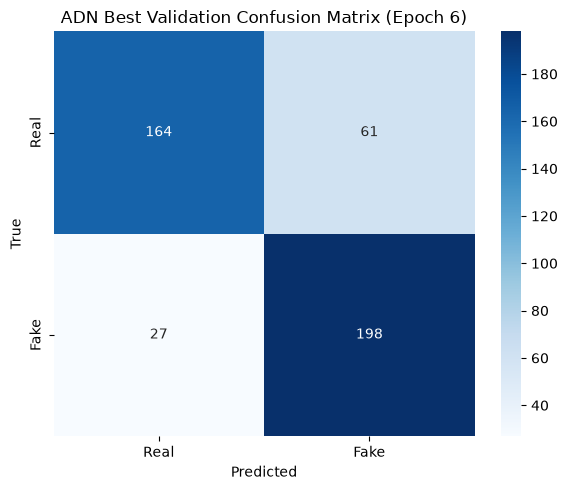

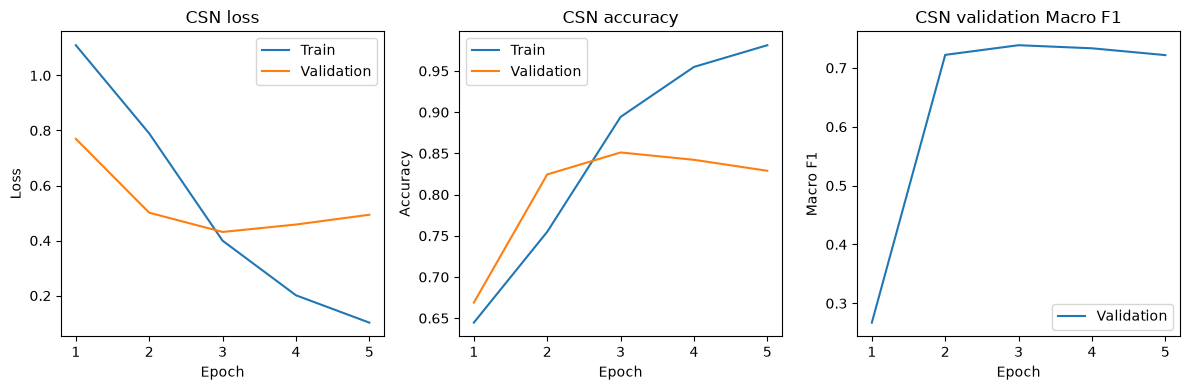

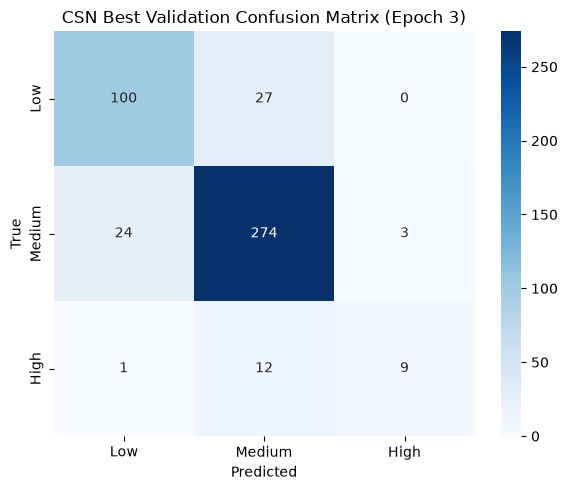

In [11]:
plot_training_history(adn_history, "ADN")
plot_training_confusion(adn_history, "ADN", adn_display_names)
plot_training_history(csn_history, "CSN")
plot_training_confusion(csn_history, "CSN", csn_display_names)


### Best checkpoints from the current training run


In [12]:
adn_checkpoint = Path(OUTPUT_DIR) / "adn_best.pt"
csn_checkpoint = Path(OUTPUT_DIR) / "csn_best.pt"

if not adn_checkpoint.exists():
    raise FileNotFoundError(f"ADN checkpoint not found: {adn_checkpoint}")

if not csn_checkpoint.exists():
    raise FileNotFoundError(f"CSN checkpoint not found: {csn_checkpoint}")

# Recreate models without downloading pretrained weights, then validate checkpoint provenance.
adn_model = ADN(pretrained=False).to(DEVICE)
csn_model = CSN(num_sensitivity_classes=len(csn_class_to_index), pretrained=False).to(DEVICE)
adn_metadata = load_checkpoint(adn_checkpoint, adn_model)
csn_metadata = load_checkpoint(csn_checkpoint, csn_model)

for task, metadata, mapping, names in (
    ("ADN", adn_metadata, adn_class_to_index, adn_class_names),
    ("CSN", csn_metadata, csn_class_to_index, csn_class_names),
):
    assert metadata["task"] == task and metadata["num_classes"] == len(mapping)
    assert metadata["class_names"] == names
    assert metadata["class_to_index"] == {str(value): int(index) for value, index in mapping.items()}

adn_model.eval()
csn_model.eval()

print(f"Loaded ADN checkpoint: {adn_checkpoint}")
print(f"ADN classes: {adn_metadata['class_names']}")
print(f"Loaded CSN checkpoint: {csn_checkpoint}")
print(f"CSN classes: {csn_metadata['class_names']}")

Loaded ADN checkpoint: SensiFakeProject-output-v2/adn_best.pt
ADN classes: ['0', '1']
Loaded CSN checkpoint: SensiFakeProject-output-v2/csn_best.pt
CSN classes: ['0', '1', '2']


## Best-checkpoint Validation


/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_577732/3901612136.py:118: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


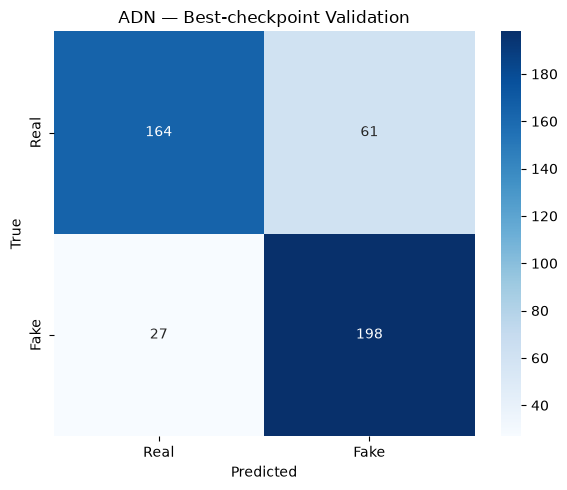

BEST ADN VALIDATION:
Epoch: 6 | Macro F1: 0.8033 | Accuracy: 0.8044 | Fake Recall: 0.8800 | Fake False Negative Rate: 0.1200


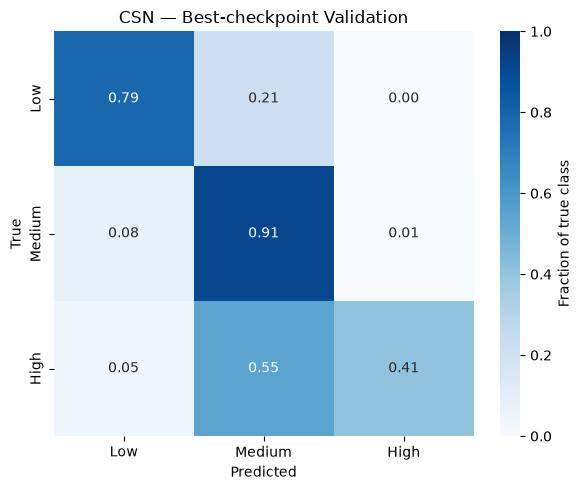

BEST CSN VALIDATION:
Epoch: 3 | Macro F1: 0.7385 | Accuracy: 0.8511 | High Recall: 0.4091 | High F1: 0.5294


In [13]:
# ADN validation: use only val_df and the best checkpoint already loaded above.
adn_val_loader = _build_loaders(
    train_df, val_df, label_col, adn_class_to_index, task="ADN"
)[1]
csn_val_loader = _build_loaders(
    train_df, val_df, sensitivity_col, csn_class_to_index, task="CSN"
)[1]
assert adn_val_loader.dataset.frame.equals(csn_val_loader.dataset.frame)
adn_validation = _evaluate(
    adn_model, adn_val_loader, nn.CrossEntropyLoss(label_smoothing=ADN_LABEL_SMOOTHING)
)
csn_validation = _evaluate(csn_model, csn_val_loader, nn.CrossEntropyLoss())
assert np.isclose(adn_validation["macro_f1"], adn_metadata["best_val_macro_f1"])
assert np.isclose(csn_validation["macro_f1"], csn_metadata["best_val_macro_f1"])

fake_index, real_index = adn_indices["fake"], adn_indices["real"]
adn_matrix = confusion_matrix(
    adn_validation["y_true"], adn_validation["y_pred"],
    labels=list(range(len(adn_class_to_index))),
)
fake_count = int(adn_matrix[fake_index].sum())
adn_validation_metrics = {
    "accuracy": adn_validation["accuracy"],
    "macro_f1": adn_validation["macro_f1"],
    "fake_recall": float(adn_matrix[fake_index, fake_index] / fake_count) if fake_count else np.nan,
    "fake_false_negative_rate": float(adn_matrix[fake_index, real_index] / fake_count) if fake_count else np.nan,
}
_save_metrics(adn_validation_metrics, "adn_validation_metrics.json")
_plot_validation_confusion(adn_validation["y_true"], adn_validation["y_pred"], adn_display_names, "ADN")
print("BEST ADN VALIDATION:")
print(f"Epoch: {adn_metadata['epoch']} | Macro F1: {adn_validation_metrics['macro_f1']:.4f} | "
      f"Accuracy: {adn_validation_metrics['accuracy']:.4f} | "
      f"Fake Recall: {adn_validation_metrics['fake_recall']:.4f} | "
      f"Fake False Negative Rate: {adn_validation_metrics['fake_false_negative_rate']:.4f}")

# CSN validation: Macro F1 and per-class metrics, including High.
csn_report = csn_validation["class_report"]
csn_validation_metrics = {
    "accuracy": csn_validation["accuracy"], "macro_f1": csn_validation["macro_f1"],
    **{name.lower(): {"precision": csn_report[name]["precision"],
                     "recall": csn_report[name]["recall"], "f1": csn_report[name]["f1-score"]}
       for name in csn_display_names},
}
_save_metrics(csn_validation_metrics, "csn_validation_metrics.json")
_plot_validation_confusion(csn_validation["y_true"], csn_validation["y_pred"],
                           csn_display_names, "CSN", normalize="true")
print("BEST CSN VALIDATION:")
print(f"Epoch: {csn_metadata['epoch']} | Macro F1: {csn_validation['macro_f1']:.4f} | "
      f"Accuracy: {csn_validation['accuracy']:.4f} | "
      f"High Recall: {csn_validation['high_recall']:.4f} | High F1: {csn_validation['high_f1']:.4f}")


## Test Set Evaluation

/tmp/ipykernel_577732/3209451107.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


ADN test metrics:
     Accuracy  Macro F1  Weighted F1  Fake Precision  Fake Recall  Fake F1  Fake False Negative Rate
ADN    0.8156    0.8146       0.8146          0.7752       0.8889   0.8282                    0.1111

CSN test metrics:
     Accuracy  Macro F1  Weighted F1
CSN    0.8311    0.7312       0.8275
        precision  recall  f1-score  support
Low        0.7782  0.7352    0.7561    253.0
Medium     0.8574  0.8987    0.8775    602.0
High       0.7000  0.4667    0.5600     45.0


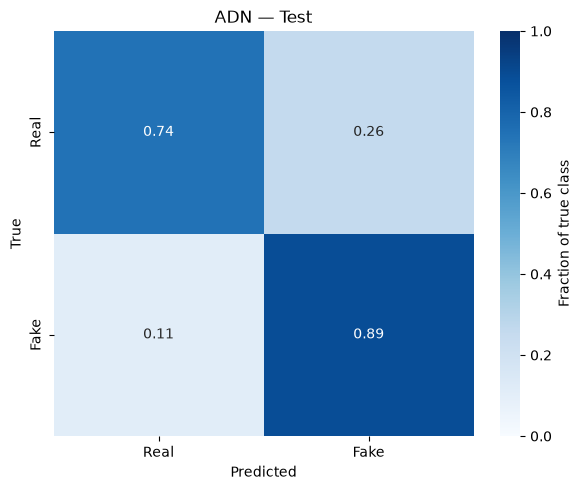

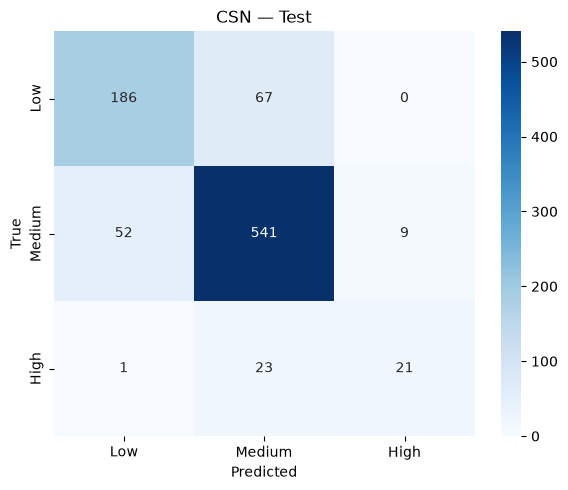

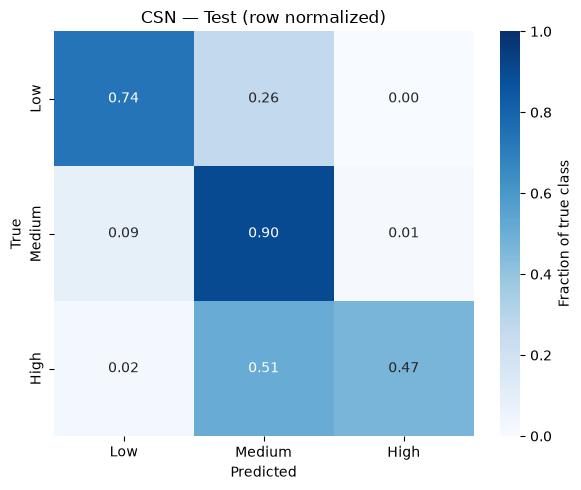

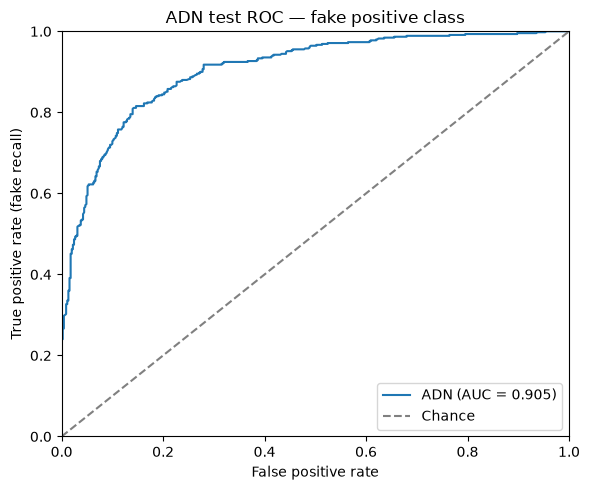


ADN by true sensitivity:
             Samples  Accuracy  Macro F1  Fake Recall  Fake False Negative Rate
Sensitivity                                                                    
Low              253    0.7352    0.7338       0.8160                    0.1840
Medium           602    0.8405    0.8403       0.9107                    0.0893
High              45    0.9333    0.9068       0.9706                    0.0294


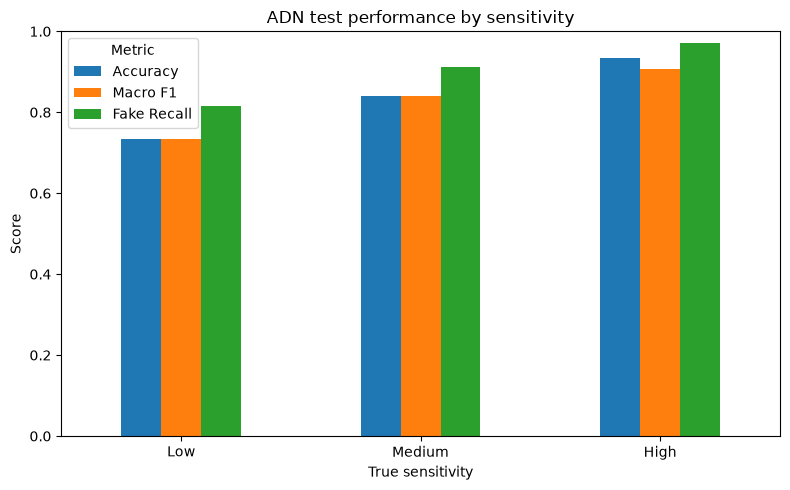

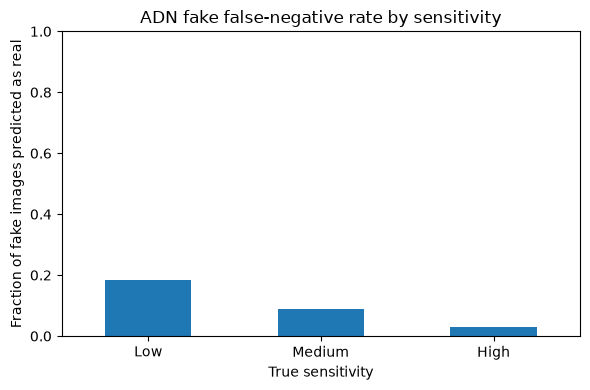

In [14]:
# Test inference: preserve loader order and collect every sample.
def _test_inference(model, loader):
    model.eval()
    y_true, probabilities = [], []
    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            with autocast(enabled=USE_AMP):
                logits = model(images)
            probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
            y_true.append(labels.cpu().numpy())
    y_true = np.concatenate(y_true)
    probabilities = np.concatenate(probabilities)
    assert len(y_true) == len(probabilities) == len(loader.dataset)
    return y_true, probabilities.argmax(axis=1), probabilities


# Metrics: class indices always come from the explicit mappings.
def _adn_test_metrics(y_true, y_pred):
    labels = list(range(len(adn_class_to_index)))
    fake_index, real_index = adn_indices["fake"], adn_indices["real"]
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    fake_count = matrix[fake_index].sum()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro F1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
        "Fake Precision": precision_score(y_true, y_pred, pos_label=fake_index, zero_division=0),
        "Fake Recall": (recall_score(y_true, y_pred, pos_label=fake_index, zero_division=0)
                        if fake_count else np.nan),
        "Fake F1": f1_score(y_true, y_pred, pos_label=fake_index, zero_division=0),
        "Fake False Negative Rate": (matrix[fake_index, real_index] / fake_count
                                     if fake_count else np.nan),
    }


def _plot_test_confusion(y_true, y_pred, names, title, ax, normalize=None):
    matrix = confusion_matrix(y_true, y_pred, labels=list(range(len(names))), normalize=normalize)
    options = ({"vmin": 0, "vmax": 1, "cbar_kws": {"label": "Fraction of true class"}}
               if normalize else {})
    sns.heatmap(matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", ax=ax,
                xticklabels=names, yticklabels=names, **options)
    ax.set(title=title, xlabel="Predicted", ylabel="True")


adn_test_loader = _build_test_loader(test_df, label_col, adn_class_to_index)
csn_test_loader = _build_test_loader(test_df, sensitivity_col, csn_class_to_index)
assert len(adn_test_loader.dataset) == len(csn_test_loader.dataset) == len(test_df)
assert adn_test_loader.dataset.frame["image_path"].equals(csn_test_loader.dataset.frame["image_path"])
adn_y_true, adn_y_pred, adn_test_probabilities = _test_inference(adn_model, adn_test_loader)
csn_y_true, csn_y_pred, csn_test_probabilities = _test_inference(csn_model, csn_test_loader)
assert np.array_equal(adn_y_true, test_df[label_col].map(adn_class_to_index).to_numpy())
assert np.array_equal(csn_y_true, test_df[sensitivity_col].map(csn_class_to_index).to_numpy())

adn_test_metrics = _adn_test_metrics(adn_y_true, adn_y_pred)
print("ADN test metrics:")
print(pd.DataFrame([adn_test_metrics], index=["ADN"]).round(4).to_string())
csn_test_metrics = {
    "Accuracy": accuracy_score(csn_y_true, csn_y_pred),
    "Macro F1": f1_score(csn_y_true, csn_y_pred, labels=list(range(len(csn_class_to_index))),
                          average="macro", zero_division=0),
    "Weighted F1": f1_score(csn_y_true, csn_y_pred, labels=list(range(len(csn_class_to_index))),
                             average="weighted", zero_division=0),
}
print("\nCSN test metrics:")
print(pd.DataFrame([csn_test_metrics], index=["CSN"]).round(4).to_string())
csn_report = classification_report(
    csn_y_true, csn_y_pred, labels=list(range(len(csn_class_to_index))),
    target_names=csn_display_names, output_dict=True, zero_division=0,
)
print(pd.DataFrame(csn_report).T.loc[csn_display_names, ["precision", "recall", "f1-score", "support"]]
      .round(4).to_string())
# Save the unrounded metrics already computed above.
_save_metrics(adn_test_metrics, "adn_test_metrics.json")
_save_metrics({**csn_test_metrics, **{name: csn_report[name] for name in csn_display_names}},
              "csn_test_metrics.json")

# Dedicated test confusion matrices; ADN is normalized by true class.
fig, ax = plt.subplots(figsize=(6, 5))
_plot_test_confusion(adn_y_true, adn_y_pred, adn_display_names, "ADN — Test", ax, normalize="true")
_save_figure(fig, "adn_test_confusion_matrix.jpg")
fig, ax = plt.subplots(figsize=(6, 5))
_plot_test_confusion(csn_y_true, csn_y_pred, csn_display_names, "CSN — Test", ax)
_save_figure(fig, "csn_test_confusion_matrix.jpg")
fig, ax = plt.subplots(figsize=(6, 5))
_plot_test_confusion(csn_y_true, csn_y_pred, csn_display_names,
                     "CSN — Test (row normalized)", ax, normalize="true")
_save_figure(fig, "csn_test_confusion_matrix_normalized.jpg")

# ROC uses the original Fake probabilities, without modifying predictions.
adn_fake_true = (adn_y_true == adn_indices["fake"]).astype(int)
if np.unique(adn_fake_true).size == 2:
    false_positive_rate, true_positive_rate, _ = roc_curve(
        adn_fake_true, adn_test_probabilities[:, adn_indices["fake"]]
    )
    adn_roc_auc = roc_auc_score(adn_fake_true, adn_test_probabilities[:, adn_indices["fake"]])
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(false_positive_rate, true_positive_rate, label=f"ADN (AUC = {adn_roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    ax.set(title="ADN test ROC — fake positive class", xlabel="False positive rate",
           ylabel="True positive rate (fake recall)", xlim=(0, 1), ylim=(0, 1))
    ax.legend()
    _save_figure(fig, "adn_roc.jpg")
else:
    print("ROC curve unavailable: the test set contains only one authenticity class.")

# ADN performance grouped by true sensitivity, reusing the same test predictions.
adn_by_sensitivity = []
for name in ("low", "medium", "high"):
    mask = csn_y_true == csn_indices[name]
    count = int(mask.sum())
    metrics = _adn_test_metrics(adn_y_true[mask], adn_y_pred[mask]) if count else {}
    adn_by_sensitivity.append({
        "Sensitivity": name.title(), "Samples": count,
        **{metric: metrics.get(metric, np.nan) for metric in
           ("Accuracy", "Macro F1", "Fake Recall", "Fake False Negative Rate")},
    })
adn_by_sensitivity = pd.DataFrame(adn_by_sensitivity).set_index("Sensitivity")
print("\nADN by true sensitivity:")
print(adn_by_sensitivity.round(4).to_string())
ax = adn_by_sensitivity[["Accuracy", "Macro F1", "Fake Recall"]].plot.bar(
    figsize=(8, 5), rot=0, ylim=(0, 1)
)
ax.set(title="ADN test performance by sensitivity", xlabel="True sensitivity", ylabel="Score")
ax.legend(title="Metric")
_save_figure(ax.figure, "adn_by_sensitivity.jpg")
ax = adn_by_sensitivity["Fake False Negative Rate"].plot.bar(figsize=(6, 4), rot=0, ylim=(0, 1))
ax.set(title="ADN fake false-negative rate by sensitivity", xlabel="True sensitivity",
       ylabel="Fraction of fake images predicted as real")
_save_figure(ax.figure, "adn_fnr_by_sensitivity.jpg")


## Fusion / Final Evaluation


In [15]:
W_H = 1
W_M = 0.66
W_L = 0.33
EPSILON = 0.036

# Class meanings are validated in Data and when loading the checkpoints.
assert set(adn_indices) == {"real", "fake"}
assert set(csn_indices) == {"low", "medium", "high"}


def apply_fusion(adn_probabilities, csn_probabilities):
    p_real = adn_probabilities[..., adn_indices["real"]]
    p_fake = adn_probabilities[..., adn_indices["fake"]]
    low_value = csn_probabilities[..., csn_indices["low"]]
    medium_value = csn_probabilities[..., csn_indices["medium"]]
    high_value = csn_probabilities[..., csn_indices["high"]]
    prudence_score = (
        high_value * W_H + medium_value * W_M + low_value * W_L
    )
    threshold = 0.5 + prudence_score * EPSILON
    result = np.where(p_real > threshold, "real", "fake")
    return prudence_score, threshold, result


prudence_score, threshold, res = apply_fusion(adn_test_probabilities, csn_test_probabilities)
fusion_y_pred = np.where(res == "real", adn_indices["real"], adn_indices["fake"])
identifier_columns = [col for col in ("image_id", "image_path") if col in test_df.columns]
test_results_df = test_df[identifier_columns].copy()
test_results_df["true_real_fake"] = test_df[label_col].to_numpy()
test_results_df["true_sensitivity"] = test_df[sensitivity_col].to_numpy()
test_results_df["p_real"] = adn_test_probabilities[:, adn_indices["real"]]
test_results_df["p_fake"] = adn_test_probabilities[:, adn_indices["fake"]]
test_results_df["p_low"] = csn_test_probabilities[:, csn_indices["low"]]
test_results_df["p_medium"] = csn_test_probabilities[:, csn_indices["medium"]]
test_results_df["p_high"] = csn_test_probabilities[:, csn_indices["high"]]
test_results_df["prudence_score"] = prudence_score
test_results_df["fusion_threshold"] = threshold
adn_index_to_value = {index: value for value, index in adn_class_to_index.items()}
test_results_df["adn_prediction"] = [adn_index_to_value[int(index)] for index in adn_y_pred]
test_results_df["fusion_prediction"] = [adn_index_to_value[int(index)] for index in fusion_y_pred]
assert len(test_results_df) == len(test_df) == len(adn_y_true) == len(fusion_y_pred)
assert test_results_df["image_path"].equals(test_df["image_path"])
test_results_df.to_csv(RESULTS_DIR / "fusion_predictions.csv", index=False)
print(f"Fusion evaluated on all {len(test_results_df)} test images.")
print(test_results_df.head().round(4).to_string(index=False))


Fusion evaluated on all 900 test images.
                                                        image_id                                                                                  image_path  true_real_fake  true_sensitivity   p_real   p_fake    p_low  p_medium   p_high  prudence_score  fusion_threshold  adn_prediction  fusion_prediction
5a5c27a6615916e32fcc6a465eef05d00b8dad4e611224e40bfbe43e0fb50b59   autoannotated/images/5a5c27a6615916e32fcc6a465eef05d00b8dad4e611224e40bfbe43e0fb50b59.png               1                 2 0.371094 0.628906 0.016006  0.227051 0.757324        0.912598          0.532715               1                  1
7fc4cb8d909eb12ef737d61f25e3bd663245c15273f961fcee6309ed49a950da human_annotated/images/7fc4cb8d909eb12ef737d61f25e3bd663245c15273f961fcee6309ed49a950da.jpg               0                 0 0.572754 0.427246 0.829590  0.140259 0.030304        0.396729          0.514160               0                  0
dbeb4276542c32846227e96eefc2cbacdba7d1b3d

/home/sarah/Desktop/University/ComputerVision/SensiFake/.venv/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


## ADN vs Sensitivity-Aware Fusion

           Accuracy  Macro F1  Fake Precision  Fake Recall  Fake F1  Fake False Negative Rate
ADN alone    0.8156    0.8146          0.7752       0.8889   0.8282                    0.1111
Fusion       0.8133    0.8117          0.7640       0.9067   0.8293                    0.0933


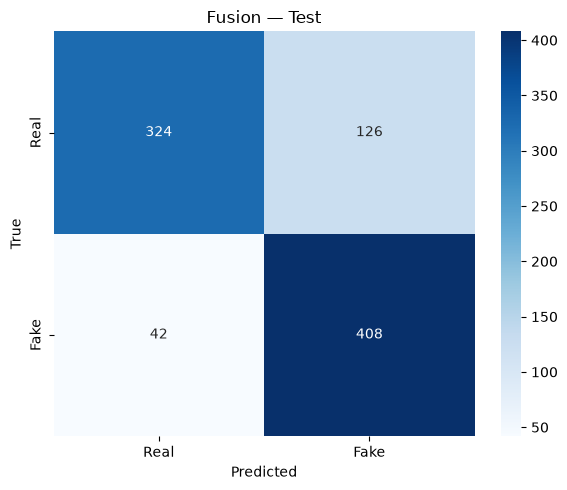


Fusion by true sensitivity:
             Samples  Accuracy  Fake Recall  Fake False Negative Rate
Sensitivity                                                          
Low              253    0.7431       0.8480                    0.1520
Medium           602    0.8339       0.9244                    0.0756
High              45    0.9333       0.9706                    0.0294
NaN: empty group or no true Fake samples for Recall/FNR.


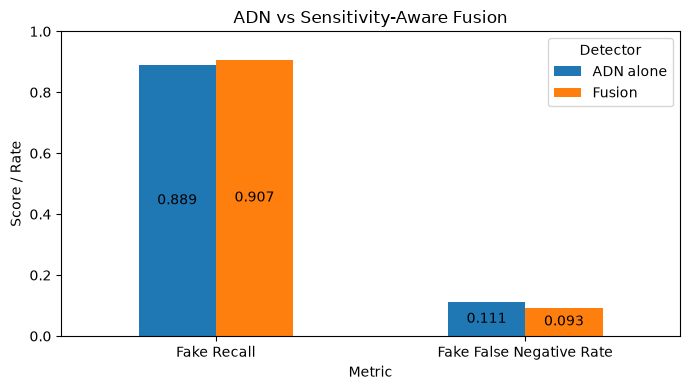


ADN vs Fusion by true sensitivity:
Sensitivity  Model  Samples  Accuracy  Fake Recall  Fake False Negative Rate
        Low    ADN      253    0.7352       0.8160                    0.1840
        Low Fusion      253    0.7431       0.8480                    0.1520
     Medium    ADN      602    0.8405       0.9107                    0.0893
     Medium Fusion      602    0.8339       0.9244                    0.0756
       High    ADN       45    0.9333       0.9706                    0.0294
       High Fusion       45    0.9333       0.9706                    0.0294


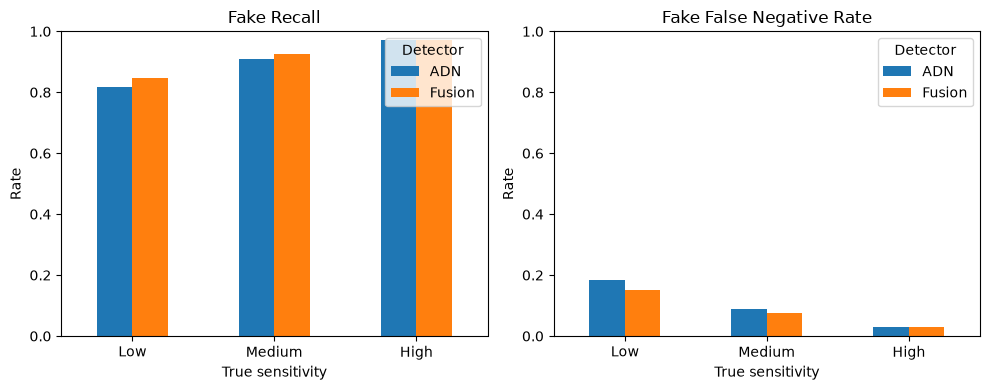


Fusion decision changes:
ADN decision Fusion decision  Samples  Changed  Corrections  Regressions
        Real            Real      366    False            0            0
        Real            Fake       18     True            8           10
        Fake            Fake      516    False            0            0
        Fake            Real        0     True            0            0

Fusion threshold by true sensitivity (population standard deviation):
Sensitivity  Samples  Mean prudence score  Std prudence score  Mean fusion threshold  Std fusion threshold
        Low      253               0.4519              0.1035                 0.5161                0.0037
     Medium      602               0.6328              0.0740                 0.5229                0.0027
       High       45               0.8096              0.1510                 0.5293                0.0054

ADN selected epoch 6: train accuracy=0.8352, validation accuracy=0.8044, accuracy gap=0.0307; test accuracy=0

In [16]:
# Both predictions refer to the same ordered test_df; no recalibration follows.
fusion_test_metrics = _adn_test_metrics(adn_y_true, fusion_y_pred)
comparison_columns = ["Accuracy", "Macro F1", "Fake Precision", "Fake Recall", "Fake F1",
                      "Fake False Negative Rate"]
adn_vs_fusion = pd.DataFrame(
    [adn_test_metrics, fusion_test_metrics],
    index=["ADN alone", "Fusion"],
)[comparison_columns]
print(adn_vs_fusion.round(4).to_string())
_save_metrics(fusion_test_metrics, "fusion_test_metrics.json")
adn_vs_fusion.to_csv(RESULTS_DIR / "adn_vs_fusion.csv", index_label="Detector")

# ADN's confusion matrix is already displayed in Test Set Evaluation.
fig, ax = plt.subplots(figsize=(6, 5))
_plot_test_confusion(adn_y_true, fusion_y_pred, adn_display_names, "Fusion — Test", ax)
_save_figure(fig, "fusion_test_confusion_matrix.jpg")

# Group by true sensitivity, not by CSN prediction.
fusion_by_sensitivity = []
for name in ("low", "medium", "high"):
    mask = csn_y_true == csn_indices[name]
    count = int(mask.sum())
    metrics = _adn_test_metrics(adn_y_true[mask], fusion_y_pred[mask]) if count else {}
    fusion_by_sensitivity.append({
        "Sensitivity": name.title(), "Samples": count,
        "Accuracy": metrics.get("Accuracy", np.nan),
        "Fake Recall": metrics.get("Fake Recall", np.nan),
        "Fake False Negative Rate": metrics.get("Fake False Negative Rate", np.nan),
    })
fusion_by_sensitivity = pd.DataFrame(fusion_by_sensitivity).set_index("Sensitivity")
assert fusion_by_sensitivity["Samples"].sum() == len(test_df)
print("\nFusion by true sensitivity:")
print(fusion_by_sensitivity.round(4).to_string())
print("NaN: empty group or no true Fake samples for Recall/FNR.")
fusion_by_sensitivity.to_csv(RESULTS_DIR / "fusion_by_sensitivity.csv", index_label="Sensitivity")

# One compact comparison highlights the change in Fake recall and missed Fakes.
ax = adn_vs_fusion[["Fake Recall", "Fake False Negative Rate"]].T.plot.bar(
    figsize=(7, 4), rot=0, ylim=(0, 1)
)
ax.set(title="ADN vs Sensitivity-Aware Fusion", xlabel="Metric", ylabel="Score / Rate")
ax.legend(title="Detector")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="center")
_save_figure(ax.figure, "adn_vs_fusion.jpg")

# Additional analyses use only the frozen predictions already evaluated above.
group_comparisons = []
threshold_groups = []
for name in ("low", "medium", "high"):
    mask = csn_y_true == csn_indices[name]
    count = int(mask.sum())
    for model_name, predictions in (("ADN", adn_y_pred), ("Fusion", fusion_y_pred)):
        metrics = _adn_test_metrics(adn_y_true[mask], predictions[mask]) if count else {}
        group_comparisons.append({
            "Sensitivity": name.title(), "Model": model_name, "Samples": count,
            **{metric: metrics.get(metric, np.nan) for metric in
               ("Accuracy", "Fake Recall", "Fake False Negative Rate")},
        })
    threshold_groups.append({
        "Sensitivity": name.title(), "Samples": count,
        "Mean prudence score": float(prudence_score[mask].mean()) if count else np.nan,
        "Std prudence score": float(prudence_score[mask].std(ddof=0)) if count else np.nan,
        "Mean fusion threshold": float(threshold[mask].mean()) if count else np.nan,
        "Std fusion threshold": float(threshold[mask].std(ddof=0)) if count else np.nan,
    })
adn_vs_fusion_by_sensitivity = pd.DataFrame(group_comparisons)
adn_vs_fusion_by_sensitivity.to_csv(RESULTS_DIR / "adn_vs_fusion_by_sensitivity.csv", index=False)
print("\nADN vs Fusion by true sensitivity:")
print(adn_vs_fusion_by_sensitivity.round(4).to_string(index=False))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ("Fake Recall", "Fake False Negative Rate")):
    values = adn_vs_fusion_by_sensitivity.pivot(index="Sensitivity", columns="Model", values=metric)
    values.reindex(["Low", "Medium", "High"])[["ADN", "Fusion"]].plot.bar(ax=ax, rot=0, ylim=(0, 1))
    ax.set(title=metric, xlabel="True sensitivity", ylabel="Rate")
    ax.legend(title="Detector")
_save_figure(fig, "adn_vs_fusion_by_sensitivity.jpg")

# Count all four transitions, including zero-count transitions.
decision_rows = []
for from_name, to_name in (("real", "real"), ("real", "fake"), ("fake", "fake"), ("fake", "real")):
    mask = ((adn_y_pred == adn_indices[from_name]) & (fusion_y_pred == adn_indices[to_name]))
    changed = from_name != to_name
    corrections = int((mask & (adn_y_pred != adn_y_true) & (fusion_y_pred == adn_y_true)).sum())
    regressions = int((mask & (adn_y_pred == adn_y_true) & (fusion_y_pred != adn_y_true)).sum())
    decision_rows.append({
        "ADN decision": from_name.title(), "Fusion decision": to_name.title(),
        "Samples": int(mask.sum()), "Changed": changed,
        "Corrections": corrections, "Regressions": regressions,
    })
fusion_decision_changes = pd.DataFrame(decision_rows)
assert fusion_decision_changes["Samples"].sum() == len(test_df)
assert (fusion_decision_changes["Corrections"].sum() + fusion_decision_changes["Regressions"].sum()
        == int((adn_y_pred != fusion_y_pred).sum()))
fusion_decision_changes.to_csv(RESULTS_DIR / "fusion_decision_changes.csv", index=False)
print("\nFusion decision changes:")
print(fusion_decision_changes.to_string(index=False))

fusion_threshold_by_sensitivity = pd.DataFrame(threshold_groups)
fusion_threshold_by_sensitivity.to_csv(RESULTS_DIR / "fusion_threshold_by_sensitivity.csv", index=False)
print("\nFusion threshold by true sensitivity (population standard deviation):")
print(fusion_threshold_by_sensitivity.round(4).to_string(index=False))

# Read generalization alongside class robustness and the fusion recall/FNR trade-off.
best_adn_epoch = int(adn_metadata["epoch"]) - 1
assert best_adn_epoch == int(np.argmax(adn_history["val_macro_f1"]))
print(f"\nADN selected epoch {best_adn_epoch + 1}: "
      f"train accuracy={adn_history['train_accuracy'][best_adn_epoch]:.4f}, "
      f"validation accuracy={adn_history['val_accuracy'][best_adn_epoch]:.4f}, "
      f"accuracy gap={adn_history['train_accuracy'][best_adn_epoch] - adn_history['val_accuracy'][best_adn_epoch]:.4f}; "
      f"test accuracy={adn_test_metrics['Accuracy']:.4f}, macro F1={adn_test_metrics['Macro F1']:.4f}, "
      f"Fake recall={adn_test_metrics['Fake Recall']:.4f}, "
      f"Fake FNR={adn_test_metrics['Fake False Negative Rate']:.4f}.")
print("Training accuracy uses augmentation and training mode; the gap is descriptive.")
print(f"CSN test macro F1={csn_test_metrics['Macro F1']:.4f}, "
      f"High recall={csn_report['High']['recall']:.4f}, High F1={csn_report['High']['f1-score']:.4f}, "
      f"accuracy={csn_test_metrics['Accuracy']:.4f}; read Low/Medium class metrics above as well.")
print("Fusion: compare Fake recall/FNR, corrections/regressions, and true-sensitivity groups above. "
      "Configuration was selected in v3 using training/validation only. These test analyses do not change training, checkpoint selection, or fusion settings.")


### Single-image demo

In [17]:
DEMO_IMAGE_PATH = Path("test_image.jpg")
if not DEMO_IMAGE_PATH.is_file():
    print(f"Demo skipped: {DEMO_IMAGE_PATH} not found in the project root.")
else:
    _, eval_transform = _make_transforms()
    demo_image = Image.open(DEMO_IMAGE_PATH).convert("RGB")
    demo_tensor = eval_transform(demo_image).unsqueeze(0).to(DEVICE)

    # The best models are already in evaluation mode; no checkpoint reload or model update.
    with torch.inference_mode():
        with autocast(enabled=USE_AMP):
            demo_adn_logits = adn_model(demo_tensor)
            demo_csn_logits = csn_model(demo_tensor)
    demo_adn_probabilities = torch.softmax(demo_adn_logits, dim=1)[0].cpu().numpy()
    demo_csn_probabilities = torch.softmax(demo_csn_logits, dim=1)[0].cpu().numpy()
    demo_adn_index = int(demo_adn_probabilities.argmax())
    demo_csn_index = int(demo_csn_probabilities.argmax())

    print(f"Image: {DEMO_IMAGE_PATH}")
    print(f"ADN prediction: {adn_display_names[demo_adn_index]}")
    print("ADN probabilities:")
    for name in ("real", "fake"):
        print(f"  {name.title()}: {demo_adn_probabilities[adn_indices[name]]:.2%}")
    print(f"\nCSN prediction: {csn_display_names[demo_csn_index]}")
    print("CSN probabilities:")
    for name in ("low", "medium", "high"):
        print(f"  {name.title()}: {demo_csn_probabilities[csn_indices[name]]:.2%}")

    demo_prudence_score, demo_threshold, demo_result = apply_fusion(
        demo_adn_probabilities, demo_csn_probabilities
    )
    print(f"\nPrudence score: {demo_prudence_score}")
    print(f"Fusion threshold: {demo_threshold}")
    print(f"Final fusion result: {demo_result.item()}")


/tmp/ipykernel_577732/297263604.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Image: test_image.jpg
ADN prediction: Fake
ADN probabilities:
  Real: 41.36%
  Fake: 58.64%

CSN prediction: Medium
CSN probabilities:
  Low: 2.58%
  Medium: 57.76%
  High: 39.62%

Prudence score: 0.78564453125
Fusion threshold: 0.5283203125
Final fusion result: fake
